# Lesson 08b: Block-by-Block Implementation of NequIP in e3nn

**What you will learn**

- Build a simplified version of NequIP (`SimpleNequIP`) from the pieces
  developed in Lesson 08a: species embedding, Bessel basis + polynomial cutoff,
  spherical harmonics of edges, weighted tensor-product interaction blocks with
  gates, and a per-atom scalar readout.
- Calculate forces from autograd and verify the energy invariance, force
  covariance, and their smoothness at the cutoff — all *before* training, because
  in an equivariant network these properties are structural, not learned.
- Package the finished architecture as an importable module in `artifacts/`, which
  Lesson 08c trains and Lesson 11 deploys.

This lesson builds and proves the architecture; it does not train it. Training,
the benchmark against the Lesson 07 baselines, and the trained checkpoint live in
[Lesson 08c](08c_nequip_training.ipynb).

**Prerequisites**: 

- [Lesson 08a](08a_nequip_theory.ipynb): Building blocks of the NequIP architecture in e3nn,
- [Lesson 03b](03b_tensor_products_e3nn.ipynb) and
  [Lesson 04](04_nonlinearities_and_gates.ipynb): weighted tensor products and gate
  nonlinearities, the two e3nn primitives the interaction block is made of.

In [1]:
import sys
sys.path.insert(0, "..")    # Make course_utils importable

import copy

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from e3nn import o3
from e3nn.nn import FullyConnectedNet, Gate

from course_utils.data import make_lj_argon_dataset, radius_graph, train_val_split
from course_utils.plotting import plot_point_cloud

torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
# dtype strategy: float32 (default) for training speed; equivariance checks use float64 copies.
print(f"torch {torch.__version__} | device: {device}")

torch 2.7.1+cu126 | device: cuda


## What we build and what we simplify

In this lesson, we implement the NequIP pipeline end to end:

$$\{\vec r_i\},\{Z_i\} \;\xrightarrow{\text{one-hot + self-interaction}}\; h_i^{(0)} \;\xrightarrow{\text{interaction blocks}}\; h_i^{(T)} \;\xrightarrow{\text{output block}}\; E_{i} \;\xrightarrow{\;\Sigma_i}\; E_\mathrm{pot} \;\xrightarrow{-\nabla\;}\; \{\vec F_i\}$$

Here, $\vec r_i$ is the position of atom $i$, $Z_i$ is its atomic number,
$h_i^{(t)}$ is the per-atom feature vector at interaction block $t$, and $E_i$
is the per-atom energy contribution. The model is trained to predict the total
potential energy $E_\mathrm{pot}$ of the system, and the forces $\vec F_i$ are
obtained by automatic differentiation of $E_\mathrm{pot}$ with respect to the
atomic positions $\vec r_i$.

Compared to the production [`nequip`](https://github.com/mir-group/nequip)
package, we simplify the model in several ways to make it more accessible for
educational purposes:

| | Production `nequip` | This notebook |
|---|---|---|
| Chemistry | Arbitrary elements; per-species output scale/shift $\sigma_{s_i}, \lambda_{s_i}$; per-species skip weights | One-hot species embedding (here, Ar and H/C/O for aspirin); one **global** learnable scale/shift; plain `o3.Linear` skip |
| Size | 32–64 features per irrep; 5-6 interaction blocks | 16 scalar / 8 vector / 4 rank-2 channels; 3 blocks |
| Training | Adam + AMSGrad; EMA of weights; plateau LR decay; early stopping | Plain Adam + step/cosine LR decay; fixed epoch budget ([Lesson 08c](08c_nequip_training.ipynb)) |
| Neighbors | ASE neighbor lists; periodic boundary conditions | Brute-force $O(N^2)$ `radius_graph`; no PBC |
| Data | High-quality *ab initio* reference calculations | Lennard-Jones argon MD (from `course_utils.data`), then rMD17 aspirin ([Lesson 08c](08c_nequip_training.ipynb)) |

Despite the differences mentioned above, everything symmetry-related operation,
such as the convolutions, filters, parity rules, gates, autograd forces, remains
faithful to the [NequIP manuscript](https://doi.org/10.1038/s41467-022-29939-5).
We adopt eV, eV/Å, and Å for the energy, force, and distance units,
respectively.

## The dataset: Lennard-Jones argon

The course helper function, `course_utils.data.make_lj_argon_dataset`, runs a
short Langevin MD simulation of 8 argon atoms with an ASE Lennard-Jones
calculator ($\varepsilon = 0.0104$ eV, $\sigma = 3.4$ Å) and records 200 frames
of positions, total energy, and forces. We split the data sample into 150 train
/ 50 validation splits. Since LJ is a pairwise potential with a simple
functional form, we can verify the model's ability to learn the correct energy
and force relationships within the course's time budget. 

In [2]:
# Load the Lennard-Jones argon
frames = make_lj_argon_dataset(n_frames=200, n_atoms=8, seed=0)

# Split into training and validation sets
train_frames, val_frames = train_val_split(frames, val_fraction=0.25, seed=0)

# Take the number of atoms from the first frame (all frames have the same number
# of atoms)
n_atoms = frames[0]["pos"].shape[0]

# Get the energies and forces from all frames for statistics
E_all = torch.tensor([f["energy"] for f in frames])
F_all = torch.cat([f["forces"] for f in frames])

# Print some statistics about the dataset
print(f"{len(train_frames)} train / {len(val_frames)} val frames, {n_atoms} atoms each")
print(f"energy   mean {E_all.mean():+.4f} eV   std {E_all.std():.4f} eV")
print(f"force    rms  {F_all.pow(2).mean().sqrt():.4f} eV/Å   max |F| {F_all.abs().max():.4f} eV/Å")

/D4/sina/PROJECTS/e3nn-course/.venv/lib/python3.13/site-packages/ase/md/langevin.py:102: FutureWarning: The implementation of `fixcm=True` in `Langevin` does not strictly sample the correct NVT distributions. The deviations are typically small for large systems but can be more pronounced for small systems. Use `fixcm=False` together with `ase.constraints.FixCom`. `fixcm` is deprecated since ASE 3.28.0 and will be removed in a future release.
  warnings.warn(msg, FutureWarning)


150 train / 50 val frames, 8 atoms each
energy   mean -0.0743 eV   std 0.0206 eV
force    rms  0.0323 eV/Å   max |F| 0.4004 eV/Å


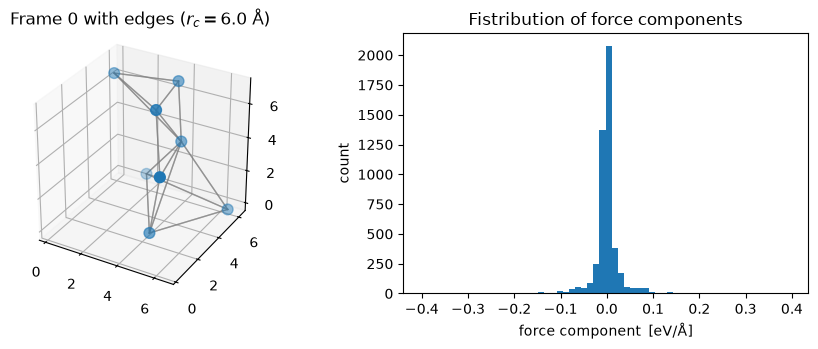

In [3]:
# Cutoff in Å: a generous value for LJ argon (well minimum at 2^(1/6); sigma is
# about 3.8 Å)
r_cut = 6.0

# Plot the first frame with edges and the distribution of force components
fig = plt.figure(figsize=(9, 3.6))
ax0 = fig.add_subplot(1, 2, 1, projection="3d")
plot_point_cloud(frames[0]["pos"], ax=ax0, edges=radius_graph(frames[0]["pos"], r_cut))
ax0.set_title(f"Frame 0 with edges ($r_c = {r_cut}$ Å)")
ax1 = fig.add_subplot(1, 2, 2)
ax1.hist(F_all.flatten().numpy(), bins=60)
ax1.set_xlabel("force component  [eV/Å]")
ax1.set_ylabel("count")
ax1.set_title("Fistribution of force components")
fig.tight_layout()
plt.show()

## Graphs and the average number of neighbors

In an atomic graph, often the edges,  $\mathcal{E}(i, j)$, connect atoms with
$r_{ij} < r_c$ and the messages flow from $j \to i$, where $\vec r_{ij} = \vec
r_j - \vec r_i$. As we have seen in Lesson 8a, the convolution operation in the
NequIP model divides the neighbor sum by $\sqrt{\bar N}$ where $\bar N$ is the
**average number of neighbors over the training set**. To make it easier for the
remaining part of this lesson, we precompute $\bar N$ and store it in the
dataset object.

In [4]:
# Compute the average number of neighbors over the training set, which is used
# in the convolution normalization
avg_num_neighbors = float(np.mean(
    [radius_graph(f["pos"], r_cut).shape[1] / n_atoms for f in train_frames]))

# Print the average number of neighbors within the cutoff radius
print(f"average number of neighbors within r_c = {r_cut} Å:  {avg_num_neighbors:.2f}")

average number of neighbors within r_c = 6.0 Å:  3.37


## Radial basis: Trainable Bessel × polynomial envelope

The radial basis functions, augmented by a polynomial envelope, are defined as:

$$B(r_{ij}) = \frac{2}{r_c}\,\frac{\sin\!\big(\tfrac{b\pi}{r_c} r_{ij}\big)}{r_{ij}}\, f_\mathrm{env}(r_{ij}, r_c),$$

where 

$$f_\mathrm{env}(x) = 1 - 28x^6 + 48x^7 - 21x^8 \;\;(x = r/r_c < 1).$$

The products $b\pi$ are initialized at the Bessel roots $b = 1, \dots, N_b$ and
**trained by backpropagation** (`nn.Parameter`), exactly as in [NequIP
manuscript](https://doi.org/10.1038/s41467-022-29939-5).

In [5]:
class BesselBasis(nn.Module):
    """Radial Bessel basis with polynomial cutoff envelope"""

    def __init__(self, r_cut: float, n_basis: int = 8, p: int = 6):
        super().__init__()
        # Store the cutoff radius, number of basis functions, and polynomial degree
        self.r_cut, self.n_basis, self.p = r_cut, n_basis, p
        
        # Trainable Bessel roots x pi, initialized at b = 1, ..., N_b
        self.b_pi = nn.Parameter(torch.pi * torch.arange(1, n_basis + 1).to(torch.float32))

    def envelope(self, x: torch.Tensor) -> torch.Tensor:
        # Compute the polynomial envelope function f_env(x) for x = r / r_cut
        p = self.p
        env = (1 - (p + 1) * (p + 2) / 2 * x**p + p * (p + 2) * x ** (p + 1)
               - p * (p + 1) / 2 * x ** (p + 2))
        
        # Zero (smoothly) beyond the cutoff
        return env * (x < 1.0)

    def forward(self, r: torch.Tensor) -> torch.Tensor:
        # Compute the Bessel basis functions for distances r
        x = r / self.r_cut
        bessel = (2.0 / self.r_cut) * torch.sin(self.b_pi * x[:, None]) / r[:, None]
        
        # Multiply by the polynomial envelope and return the result
        return bessel * self.envelope(x)[:, None]

Let's visualize the Bessel basis functions with the polynomial envelope. 

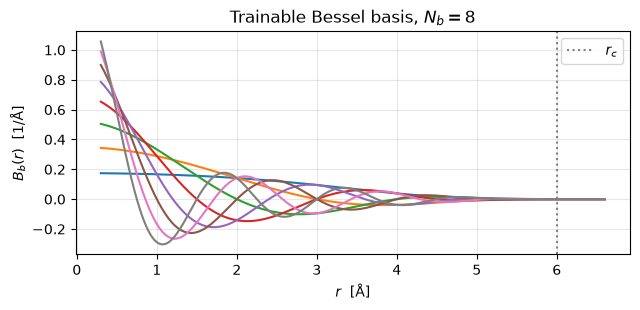

Basis at r_c: max |B| = 0.00e+00  (smoothly --> 0)


In [6]:
# Create a Bessel basis instance with the specified cutoff radius
basis = BesselBasis(r_cut)

# Create a range of distances from 0.3 Å to 1.1 times the cutoff radius, with
# 300 points
r = torch.linspace(0.3, 1.1 * r_cut, 300)

# Compute the Bessel basis functions for the range of distances without tracking
# gradients
with torch.no_grad():
    B = basis(r)

# Plot the Bessel basis functions
fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.plot(r, B)
ax.axvline(r_cut, color="gray", ls=":", label="$r_c$")
ax.set_xlabel("$r$  [Å]")
ax.set_ylabel("$B_b(r)$  [1/Å]")
ax.set_title(f"Trainable Bessel basis, $N_b = {basis.n_basis}$")
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()
print(f"Basis at r_c: max |B| = {basis(torch.tensor([r_cut - 1e-9])).abs().max():.2e}  (smoothly --> 0)")

## The interaction block

In Lesson 08a, we have introduced two small factory helpers to keep the
structure of the interaction blocks readable:

- `gate_for(irreps_out)`: The SiLU-based `Gate` where scalar features are not
  gated. Instead, even scalars are directly processed by SiLU, and odd scalars
  go through tanh. Higher-order $l>0$ features are gated together with extra
  even scalars.

- `weighted_tp(...)`: The `'uvu'` `o3.TensorProduct`, which has one path per
  interaction combination, allowed by the selection rules $|l_i - l_f| \le l_o
  \le l_i + l_f$ and $p_o = p_i p_f$. Here, the parameter `shared_weights=False`
  is set so that the weights can come **per edge** from the radial MLP.

Let's implement the two helper functions

In [7]:
def gate_for(irreps_out: o3.Irreps) -> Gate:
    """SiLU-based gate producing `irreps_out` (even scalars --> SiLU; odd
    scalars --> tanh)."""
    
    # Separate the output irreps into scalars (l=0) and gated irreps (l>0)
    irreps_scalars = o3.Irreps([(m, ir) for m, ir in irreps_out if ir.l == 0])
    irreps_gated = o3.Irreps([(m, ir) for m, ir in irreps_out if ir.l > 0])
    irreps_gates = o3.Irreps([(m, "0e") for m, _ in irreps_gated])
    
    # Define the activation functions for even and odd scalars
    act = {1: torch.nn.functional.silu, -1: torch.tanh}
    
    # Create and return a Gate instance with the specified irreps and activation
    # functions
    return Gate(irreps_scalars, [act[ir.p] for _, ir in irreps_scalars],
                irreps_gates, [torch.nn.functional.silu for _ in irreps_gates], irreps_gated)


def weighted_tp(irreps_in: o3.Irreps, irreps_sh: o3.Irreps, irreps_query: o3.Irreps):
    """'uvu' tensor product feature (x) filter with one path per allowed
    (l_i,l_f) --> l_o; per-edge weights come from MLP (shared_weights=False)."""
    
    # Compute the tensor product instructions and intermediate irreps based on the
    # input irreps, spherical harmonics irreps, and query irreps
    instructions, irreps_mid = [], []
    for i_1, (mul, ir_in) in enumerate(irreps_in):
        for i_2, (_, ir_sh) in enumerate(irreps_sh):
            # |l1-l2| <= l_o <= l1+l2;
            # p_o = p1 p2
            for ir_o in ir_in * ir_sh:
                if ir_o in irreps_query:
                    instructions.append((i_1, i_2, len(irreps_mid), "uvu", True))
                    irreps_mid.append((mul, ir_o))
    
    # Sort the intermediate irreps and update the instructions accordingly
    irreps_mid = o3.Irreps(irreps_mid)
    irreps_mid, permut, _ = irreps_mid.sort()
    instructions = [(i_1, i_2, permut[k], mode, train)
                    for i_1, i_2, k, mode, train in instructions]
    
    # Create and return a TensorProduct instance with the specified irreps and instructions
    return o3.TensorProduct(irreps_in, irreps_sh, irreps_mid, instructions,
                            shared_weights=False, internal_weights=False)

The block itself follows the sequence of self-interaction $\to$ convolution
$\to$ concatenation $\to$ self-interaction which are added to a self-interaction
skip path followed by the gate nonlinearity:

$$x^{k+1} =
\mathrm{Gate}\Big(\underbrace{\mathrm{Linear}\big(\tfrac{1}{\sqrt{\bar N}}
{\textstyle\sum_{j}} \; \mathrm{TensorProduct}\big[\mathrm{Linear}(x^k_j),\,
Y(\hat r_{ij});\, R(r_{ij})\big]\big)}_{f(x^k)} \;+\;
\underbrace{\mathrm{Linear}(x^k_i)}_{\text{skip connection}}\Big)$$

Here, the single species $\to$ the skip connection, `o3.Linear`, replaces the
NequIP's original per-species self-interaction layer.

In [8]:
class InteractionBlock(nn.Module):
    """One NequIP interaction block: conv + self-interactions + ResNet skip +
    gate."""

    def __init__(self, irreps_in, irreps_sh, irreps_out, n_basis=8, radial_neurons=64,
                 avg_num_neighbors=10.0):
        super().__init__()
        # Convert the input and spherical harmonics irreps to e3nn Irreps objects
        irreps_in, irreps_sh = o3.Irreps(irreps_in), o3.Irreps(irreps_sh)
        
        # Store the average number of neighbors for normalization in the forward pass
        self.avg_num_neighbors = avg_num_neighbors
        
        # Create a gate for the output irreps, which will be used to apply non-linearities
        self.gate = gate_for(o3.Irreps(irreps_out))
        
        # Define the linear layer for self-interaction (pre-processing)
        self.lin_pre = o3.Linear(irreps_in, irreps_in)
        
        # Define the weighted tensor product for the interaction block, which
        # combines the input features with the spherical harmonics features
        self.tp = weighted_tp(irreps_in, irreps_sh, self.gate.irreps_in)
        
        # Define the radial MLP that generates per-edge weights for the tensor product
        # 3 hidden layers, SiLU
        self.radial_mlp = FullyConnectedNet(
            [n_basis, radial_neurons, radial_neurons, radial_neurons, self.tp.weight_numel],
            torch.nn.functional.silu)
        
        # Define the linear layer for post-processing after the tensor product
        # and aggregation
        self.lin_post = o3.Linear(self.tp.irreps_out.simplify(), self.gate.irreps_in)
        
        # Define the skip connection for the ResNet-style skip connection, which
        # allows the input features to bypass the interaction block and be added to the output
        self.sc = o3.Linear(irreps_in, self.gate.irreps_in)
        
        # Store the output irreps for reference
        self.irreps_out = self.gate.irreps_out

    def forward(self, h, edge_index, edge_sh, edge_basis):
        # messages flow j -> i
        recv, send = edge_index
        
        # Apply the pre-processing linear layer to the input features
        x = self.lin_pre(h)
        
        # Compute the messages using the weighted tensor product, where the
        # weights are generated by the radial MLP based on the edge basis
        msg = self.tp(x[send], edge_sh, weight=self.radial_mlp(edge_basis))
        
        # Aggregate the messages by summing them for each receiving node and normalize
        agg = torch.zeros(h.shape[0], msg.shape[1], dtype=h.dtype, device=h.device)
        
        # sum_j / sqrt(N)
        agg = agg.index_add_(0, recv, msg) / self.avg_num_neighbors**0.5
        
        # x^{k+1} = f(x^k) + SI(x^k)
        return self.gate(self.lin_post(agg) + self.sc(h))

## The full model

Below, we present the full implementation of `SimpleNequIP` which assembles:
embedding $\to$ 3 x interaction blocks $\to$ output block (self-interaction to
`16x0e`, then to `1x0e`) $\to$ global scale/shift $\to$ global pooling
(summation). Hidden features use $l_\text{max} = 2$ with even and odd parities:
`16x0e + 16x0o + 8x1o + 8x1e + 4x2e + 4x2o`.

The learnable `energy_scale` / `energy_shift` are the single-species version of
the per-species $\sigma_{s_i}, \lambda_{s_i}$. Following the [NequIP
manuscript](https://doi.org/10.1038/s41467-022-29939-5), we will initialize them
to the root-mean-square of the training force components and the mean per-atom
training energy.

In [9]:
class SimpleNequIP(nn.Module):
    """Simplified NequIP; The species enter via a one-hot embedding."""

    def __init__(self, r_cut=6.0, n_species=1, n_basis=8, l_max=2, n_layers=3,
                 mul0=16, mul1=8, mul2=4, radial_neurons=64, avg_num_neighbors=10.0):
        super().__init__()
        
        # Store the hyperparameters in a dictionary for reference
        self.hparams = dict(r_cut=r_cut, n_species=n_species, n_basis=n_basis, l_max=l_max,
                            n_layers=n_layers, mul0=mul0, mul1=mul1, mul2=mul2,
                            radial_neurons=radial_neurons, avg_num_neighbors=avg_num_neighbors)
        
        # Store the cutoff radius and number of species for reference
        self.r_cut, self.n_species = r_cut, n_species
        
        # Filter Y up to l_max
        self.irreps_sh = o3.Irreps.spherical_harmonics(l_max)
        
        # B(r)
        self.basis = BesselBasis(r_cut, n_basis)
        
        # Define the hidden irreps for the interaction blocks based on the
        # specified multiplicities and maximum angular momentum
        irreps_hidden = o3.Irreps(f"{mul0}x0e + {mul0}x0o + {mul1}x1o + {mul1}x1e"
                                  + (f" + {mul2}x2e + {mul2}x2o" if l_max >= 2 else ""))
        
        # One-hot Z -> scalars
        self.embedding = o3.Linear(o3.Irreps(f"{n_species}x0e"),
                                   o3.Irreps(f"{mul0}x0e"))
        
        # Create a list of interaction blocks, each consisting of a convolution,
        # self-interaction, ResNet skip connection, and gate
        blocks, irreps = [], o3.Irreps(f"{mul0}x0e")
        for _ in range(n_layers):
            block = InteractionBlock(irreps, self.irreps_sh, irreps_hidden,
                                     n_basis, radial_neurons, avg_num_neighbors)
            blocks.append(block)
            irreps = block.irreps_out
        self.blocks = nn.ModuleList(blocks)
        self.out1 = o3.Linear(irreps, o3.Irreps("16x0e"))           # output block: l=0 features
        self.out2 = o3.Linear(o3.Irreps("16x0e"), o3.Irreps("1x0e"))
        
        # Define trainable parameters for energy scaling and shifting, which are
        # used to adjust the predicted energies
        self.energy_scale = nn.Parameter(torch.tensor(1.0))
        self.energy_shift = nn.Parameter(torch.tensor(0.0))

    def forward(self, pos, edge_index, species=None, batch=None):
        """pos (N,3), edge_index (2,E) [receiver, sender], species (N,) int or None,
        batch (N,) graph id or None  -->  total energy per graph, shape (n_graphs,)."""
        
        # If the batch information is not provided, create a default batch
        # tensor with all zeros
        if batch is None:
            batch = torch.zeros(pos.shape[0], dtype=torch.long, device=pos.device)
        if species is None:
            # Single species: all ones
            one_hot = torch.ones(pos.shape[0], self.n_species, dtype=pos.dtype, device=pos.device)
        else:
            one_hot = torch.nn.functional.one_hot(species, self.n_species).to(pos.dtype)
            
        # Course convention: messages flow j -> i
        recv, send = edge_index
        
        # r_ij = r_j - r_i
        vec = pos[send] - pos[recv]
        
        # Compute the spherical harmonics and Bessel basis for the edge vectors
        # Y(\hat r_ij)
        edge_sh = o3.spherical_harmonics(self.irreps_sh, vec, normalize=True,
                                         normalization="component")
        # B(r_ij)
        edge_basis = self.basis(vec.norm(dim=-1))
        
        # Pass the one-hot encoded species through the embedding layer to obtain
        # initial node features
        h = self.embedding(one_hot)
        for block in self.blocks:
            h = block(h, edge_index, edge_sh, edge_basis)
        
        # Compute the per-atom energies using the output layers and apply the
        # energy scaling and shifting
        e_atom = self.energy_scale * self.out2(self.out1(h)).squeeze(-1) + self.energy_shift
        
        # Determine the number of graphs in the batch based on the maximum batch
        # index
        n_graphs = int(batch.max()) + 1
        
        # E_pot = sum_i E_i
        return torch.zeros(n_graphs, dtype=pos.dtype, device=pos.device).index_add_(0, batch, e_atom)

### Calculating forces using autograd

The helper function, `energy_and_forces`, differentiates the summed total energy
with respect to positions. The `create_graph` (the input to
`torch.autograd.grad`) is enabled in training mode, so the force error can
itself be backpropagated (double backward).

In [10]:
def energy_and_forces(model, pos, edge_index, species=None, batch=None):
    """E_pot per graph and F = -dE/dr via autograd."""
    
    # Set the requires_grad attribute of the position tensor to True, allowing
    # gradients to be computed with respect to it
    pos = pos.requires_grad_(True)
    
    # Compute the total energy for the given positions, edge indices, species,
    # and batch
    E = model(pos, edge_index, species=species, batch=batch)
    
    # Compute the forces as the negative gradient of the summed energy with
    # respect to the positions, enabling the creation of a computation graph for
    # backpropagation
    F = -torch.autograd.grad(E.sum(), pos, create_graph=model.training)[0]
    
    # Return the computed energies and forces
    return E, F

Now, let's initialize the model and print the numner of parameters as well as
the input and output irreps for each interaction block.

In [11]:
# Instantiate the SimpleNequIP model with the specified cutoff radius and
# average number of neighbors
model = SimpleNequIP(r_cut=r_cut, avg_num_neighbors=avg_num_neighbors)

# Calculate the total number of parameters in the model and print it
n_params = sum(p.numel() for p in model.parameters())
print(f"SimpleNequIP: {n_params:,} parameters")

# Print the input and output irreps for each interaction block in the model
for k, block in enumerate(model.blocks):
    print(f"  block {k}:  in {block.lin_pre.irreps_in}   out {block.irreps_out}")

SimpleNequIP: 70,762 parameters
  block 0:  in 16x0e   out 16x0e+16x0o+8x1o+8x1e+4x2e+4x2o
  block 1:  in 16x0e+16x0o+8x1o+8x1e+4x2e+4x2o   out 16x0e+16x0o+8x1o+8x1e+4x2e+4x2o
  block 2:  in 16x0e+16x0o+8x1o+8x1e+4x2e+4x2o   out 16x0e+16x0o+8x1o+8x1e+4x2e+4x2o


## Architecture verification

### Energy invariance and force covariance

The untrained network (with random weights) must already satisfy, for every
rotation/inversion $g \in O(3)$ and translation $\vec t$:

$$E(g\,\vec r + \vec t) = E(\vec r), \qquad \vec F_i(g\,\vec r + \vec t) = g\, \vec F_i(\vec r).$$

Forces are *odd* vectors (`1o`). So, under inversion, both positions and forces
flip sign. The code block below includes improper elements ($g = -R$) half the
time it samples a random rotation. Therefore, we perform our equivariance test
in **float64** so that we can ensure that any genuine symmetry violation cannot
hide inside a **float32 round-off** per course policy.

In [12]:
# Untrained model, initialized with random weights
model64 = copy.deepcopy(model).to(torch.float64).eval()

# Initialize the positions and edges with float64 precision
# float64 (8, 3)
pos0 = frames[0]["pos"].clone()
edges0 = radius_graph(pos0, r_cut)

# Compute the energy and forces for the initial positions and edges using the
# untrained model
E0, F0 = energy_and_forces(model64, pos0.clone(), edges0)

# Check energy invariance and force covariance under random rotations,
# inversions, and translations
err_E, err_F = 0.0, 0.0
for trial in range(8):
    
    # Generate a random rotation matrix g from the O(3) group with float64 precision
    g = o3.rand_matrix(dtype=torch.float64)
    
    # Include improper elements (inversions) half the time by negating the rotation matrix
    if trial % 2:
        g = -g
        
    # Generate a random translation vector t with float64 precision
    t = torch.randn(3, dtype=torch.float64)
    
    # Compute the energy and forces for the transformed positions using the
    # untrained model
    Eg, Fg = energy_and_forces(model64, pos0 @ g.T + t, edges0)
    
    # Update the maximum errors for energy invariance and force covariance by
    # comparing the transformed energies and forces with the original ones
    # E(g r + t) = E(r)
    err_E = max(err_E, (Eg - E0).abs().max().item())
    
    # F(g r + t) = g F(r)
    err_F = max(err_F, (Fg - F0 @ g.T).abs().max().item())

# Assert that the maximum errors for energy invariance and force covariance are
# below the specified tolerance (1e-10) and print the results
assert err_E < 1e-10 and err_F < 1e-10

# Print the maximum errors for energy invariance and force covariance in scientific notation
print(f"energy invariance:  max |ΔE| = {err_E:.2e}")
print(f"force covariance:   max |ΔF| = {err_F:.2e}   (rotations, inversions, translations)")

energy invariance:  max |ΔE| = 3.11e-14
force covariance:   max |ΔF| = 9.45e-14   (rotations, inversions, translations)


### Smoothness at the cutoff

The polynomial envelope, $f_{\text{env}}$, is the key object that allows us to
avoid having a discontinuous potential-energy surface. In order to test the
smoothness of the potential-energy surface at the cutoff, we drag one atom of a
toy dimer system through $r = r_c$ and monitor the $E(r)$ and the force values
(both must smoothly go to the isolated-atom limits). Note that this is an
architectural property and the model is still untrained at this point: The
actual values of the energy and forces are meaningless here, but the smoothness
is structural.

|ΔE| across r_c between adjacent scan points: 1.76e-12   --> smooth


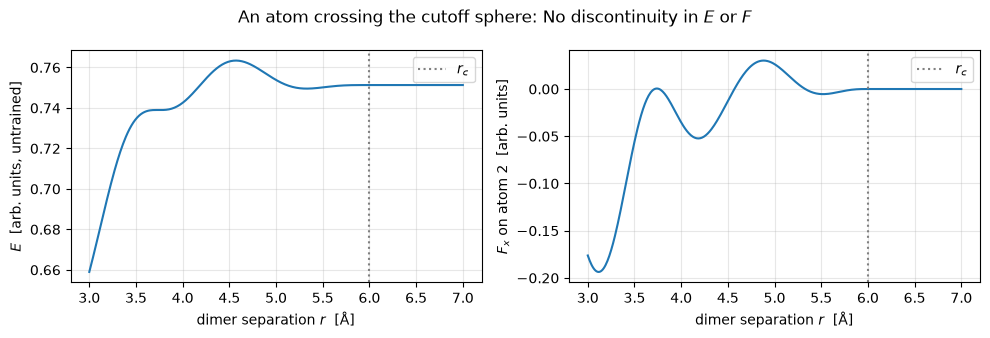

In [13]:
# Create a range of distances from 3.0 Å to 7.0 Å with 400 points, using float64
# precision
r_scan = torch.linspace(3.0, 7.0, 400, dtype=torch.float64)

# Perform a scan of energies and forces for a dimer system as one atom is moved
# through the cutoff radius, and store the results in E_scan and F_scan
E_scan, F_scan = [], []
for r_val in r_scan:
    
    # Define the positions of the two atoms in the dimer system, with one atom
    # at the origin and the other at a distance r_val along the x-axis
    p2 = torch.tensor([[0.0, 0, 0], [r_val, 0, 0]], dtype=torch.float64)
    
    # Compute the edges for the dimer system using the radius_graph function
    # with the specified cutoff radius
    e2 = radius_graph(p2, r_cut)
    
    # Compute the energy and forces for the dimer system using the untrained
    # model
    E, F = energy_and_forces(model64, p2, e2)
    
    # Append the computed energy and the x-component of the force on atom 2 to the
    # respective scan lists
    E_scan.append(E.item())
    F_scan.append(F[1, 0].item())

# Convert the scan results to NumPy arrays for further analysis and plotting
E_scan, F_scan = np.array(E_scan), np.array(F_scan)


# Check for discontinuities in energy across the cutoff radius by finding the
# last point inside the cutoff and calculating the jump in energy between that
# point and the next point outside the cutoff. Assert that the jump is below a
# specified threshold (1e-6) and print the result.
i_c = int((r_scan < r_cut).sum()) - 1
jump = abs(E_scan[i_c + 1] - E_scan[i_c])
assert jump < 1e-6, f"energy jumps by {jump:.2e} at the cutoff!"
print(f"|ΔE| across r_c between adjacent scan points: {jump:.2e}   --> smooth")

# Plot the energy and force scans as a function of dimer separation, with
# vertical lines indicating the cutoff radius and appropriate labels and titles.
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4), sharex=True)
axes[0].plot(r_scan, E_scan)
axes[0].set_ylabel("$E$  [arb. units, untrained]")
axes[1].plot(r_scan, F_scan)
axes[1].set_ylabel("$F_x$ on atom 2  [arb. units]")
for ax in axes:
    ax.axvline(r_cut, color="gray", ls=":", label="$r_c$")
    ax.set_xlabel("dimer separation $r$  [Å]")
    ax.grid(alpha=0.3)
    ax.legend()
fig.suptitle("An atom crossing the cutoff sphere: No discontinuity in $E$ or $F$")
fig.tight_layout()
plt.show()

## Packaging the architecture

The class definitions above are the deliverables of this lesson, and two
subsequent lessons will use them: [Lesson 08c](08c_nequip_training.ipynb) trains
the `SimpleNequIP` model and [Lesson 11](11_molecular_dynamics_ase.ipynb) drives
a molecular dynamics simulation with the pre-trained model. Rather than copying
several hundred lines of code into each lesson, we write the definitions out
once as an ordinary importable module, `artifacts/nequip_model.py`.

Note what this step does not need: any training. The file is extracted from the
code cells of this notebook. Thus, it is a faithful copy of the architecture you
just read and verified.

In [14]:
import json, pathlib, re

art_dir = pathlib.Path("artifacts")
art_dir.mkdir(exist_ok=True)

# `inspect.getsource` cannot see sources of objects defined in notebook cells when the
# notebook is executed non-interactively, so we extract the definitions from this
# notebook's own JSON instead.
NAMES = ["gate_for", "weighted_tp", "BesselBasis", "InteractionBlock", "SimpleNequIP",
         "energy_and_forces"]

HEADER = '''"""Simplified NequIP (Batzner et al., Nat. Commun. 13, 2453, 2022) for the e3nn course.

Auto-generated by notebooks/08b_nequip_implementation.ipynb: do not edit by hand;
re-run that notebook to regenerate. Consumed by Lesson 08c (training) and
Lesson 11 (molecular dynamics with ASE).
"""

import torch
from torch import nn
from e3nn import o3
from e3nn.nn import FullyConnectedNet, Gate

'''

own = json.load(open("08b_nequip_implementation.ipynb"))
blocks = {}
for cell in own["cells"]:
    if cell["cell_type"] != "code":
        continue
    src = "".join(cell["source"])
    for name in NAMES:
        m = re.search(rf"^(?:def|class) {name}\b.*?(?=^\S|\Z)", src, re.M | re.S)
        if m:
            blocks[name] = m.group(0).rstrip() + "\n"

missing = [n for n in NAMES if n not in blocks]
assert not missing, f"could not extract: {missing}"
source = HEADER + "\n\n".join(blocks[n] for n in NAMES)
(art_dir / "nequip_model.py").write_text(source)
print(f"wrote {art_dir / 'nequip_model.py'} ({len(source.splitlines())} lines)")

wrote artifacts/nequip_model.py (257 lines)


### Round-trip check

In order to make sure the `SimpleNequIP` implementation in
`./artifacts.nequip_model` reproduces the exact model object from this notebook,
we import it back from the module and reinstantiate it with the same
hyperparameters. 

In [15]:
import importlib

# Make ./artifacts importable
sys.path.insert(0, "")                                    
import artifacts.nequip_model

# Pick up the freshly written file
importlib.reload(artifacts.nequip_model)
from artifacts.nequip_model import SimpleNequIP as PackagedNequIP
from artifacts.nequip_model import energy_and_forces as packaged_energy_and_forces

# Rebuild from the generated source and copy in this notebook's (untrained)
# weights
packaged = PackagedNequIP(**model.hparams)
packaged.load_state_dict(model.state_dict())
packaged.eval()

# Compare the predictions of the original model and the packaged model on the first frame
pos_check = frames[0]["pos"].to(torch.float32)
edges_check = radius_graph(pos_check, r_cut)
E_a, F_a = energy_and_forces(model.eval(), pos_check.clone(), edges_check)
E_b, F_b = packaged_energy_and_forces(packaged, pos_check.clone(), edges_check)

# Assert that the energies and forces from both models are close within a
# specified tolerance (1e-7)
assert torch.allclose(E_a, E_b, atol=1e-7) and torch.allclose(F_a, F_b, atol=1e-7)

# Print the maximum absolute differences in energy and forces between the
# original model and the packaged model, confirming that they reproduce the same
# predictions
print(f"packaged model reproduces predictions: max |ΔE| = {(E_a - E_b).abs().max():.2e} eV, "
      f"max |ΔF| = {(F_a - F_b).abs().max():.2e} eV/Å")

packaged model reproduces predictions: max |ΔE| = 0.00e+00 eV, max |ΔF| = 0.00e+00 eV/Å


<div style="background: rgba(33, 150, 243, 0.10); border-left: 4px solid #2196f3; padding: 0.6em 1em; margin: 0.8em 0; border-radius: 0 4px 4px 0;"> 

<b>Note:</b> The reference implementation of NequIP is hosted at <a
href="https://github.com/mir-group/nequip"
target="_blank">github.com/mir-group/nequip</a> and can be installed using
<code>pip install nequip</code>. We have implemented a simplified version of the
architecture in this lesson for educational purposes. The production
implementation of NequIP is more complex, with per-species scale/shift and skip
weights, proper periodic-boundary neighbor lists, and multi-element datasets. 
</div>

## Summary

In this lesson, we have learned:

- How to implement a simplified version of NequIP (`SimpleNequIP`) from
  assembling one-hot species embedding $\to$ interaction blocks (weighted
  tensor-product convolution with per-edge radial weights from a Bessel-basis
  MLP, self-interaction blocks, ResNet skip connection, and SiLU gates) $\to$
  scalar output block $\to$ global pooling (total energy as a summation of
  atomic/node energies) $\to$ atomic forces (autograd).

 - How to verify the energy invariance and force covariance under random
  rotations, inversions, and translations ($\approx$ 1e-13), and smoothness of
  $E$ and $F$ as an atom crosses the cutoff sphere. None of these tests depend
  on the weights, which is the point: symmetry is built into the architecture
  rather than fitted.

- How to implement `SimpleNequIP` as a stand-alone module (as in
  `artifacts/nequip_model.py`). We have demonstrated that the generated model
  from our module can reproduce this notebook's model preictions exactly.

**Next**: [Lesson 08c](08c_nequip_training.ipynb) trains the `SimpleNequIP`
model developed and packaged in this lesson: first on LJ argon dataset with the
paper's joint energy + force loss, then on rMD17 aspirin dataset alongside
comparing its performance against the SchNet and DimeNet baselines of Lessons
07a-c.

## Exercises

**1. Break the envelope:** Replace `envelope` with a hard cutoff (`return (x <
1.0).to(x.dtype)`) in a copy of `BesselBasis` and rerun the dimer scan of the
smoothness check. What happens to $E(r)$ and $F(r)$ at $r_c$, and what would
this do in a long MD run?

<details><summary>Solution</summary>

$E(r)$ behaves like a step function at $r = r_c$ (the $b$-th Bessel function
does not vanish at $r_c$ as $\sin(b\pi)$ is zero only when $b\pi$ stays at its
integer multiples of $\pi$ initialization values and after training, it does not
stay that way), and the force shows a spike or discontinuity. In MD, every
cutoff crossing then injects or removes energy: the total energy drifts and the
thermostat masks a systematically wrong dynamics.
</details>

**2. Read the irreps:** Instantiate `SimpleNequIP` with `l_max=1` and with
`l_max=2` and print `block.irreps_out` for each interaction block (as the cell
after the model definition in the text does). Which output irreps appear only at
`l_max=2`, and which combination of input and filter orders can produce them?
Check your answer against the triangle rule $|l_i - l_f| \le l_o \le l_i + l_f$
and the parity rule $p_o = p_i p_f$.

<details><summary>Solution</summary>

At `l_max=2` the hidden irreps gain `2e`/`2o` channels. A rank-2 output can
arise as $1 \otimes 1 \to 2$ (two vectors), as well as $0 \otimes 2$, $2 \otimes
0$, or $1\otimes 2$, $2 \otimes 1$, $2\otimes 2$. Note how the $p_f =
(-1)^{l_f}$ (because of the properties of spherical harmonics) affects the
even/odd labels following from the parity rule, $p_o = p_i p_f$. For example,
$1o \otimes 1o \to 2e$. Also, pay attention to the blocks' `irreps_out`, which
do not grow without bounds: the model truncates at `l_max`, which is what
keeping the computational cost of the tensor products affordable.
</details>

**3. Break the symmetry on purpose:** The equivariance verification cells in the
text pass for any weights. Here, we're going to make them fail and learn from
this failure. In a copy of `InteractionBlock.forward`, add a constant to the 
$l > 0$ components of the output (for instance, add `0.1` to the whole feature
tensor rather than only its scalar part), then rerun the rotation/inversion
check. How large is the equivariance error, and why does adding a constant to
scalars remain harmless?

<details><summary>Solution</summary>

Patching `forward` rather than the weights keeps everything else in the model
identical. So, any change in the check below comes only from the added constant:

```python
import types

# Column ranges of the components whose irrep satisfies keep(ir).
def slices_of(irreps, keep):
    out, offset = [], 0
    for mul, ir in irreps:
        if keep(ir):
            out.append((offset, offset + mul * ir.dim))
        offset += mul * ir.dim
    return out

# A copy of `model` whose blocks add `eps` to the components selected by `keep`.
def biased_copy(model, keep, eps=0.1):
    # Deep copy the model so that the original remains unchanged.
    m = copy.deepcopy(model)

    # Loop over the blocks and patch their forward methods to add eps to the selected components.
    for block in m.blocks:

        # Unbound: Avoids recursion
        base = type(block).forward

        # Find the column ranges of the components to be perturbed.
        sl = slices_of(block.irreps_out, keep)

        # Patch the forward method to add eps to the selected components.
        def patched(self, h, edge_index, edge_sh, edge_basis, _base=base, _sl=sl):
            out = _base(self, h, edge_index, edge_sh, edge_basis).clone()
            for a, b in _sl:
                out[:, a:b] += eps
            return out
        block.forward = types.MethodType(patched, block)
    return m

# max |E(g r + t) - E(r)| and max |F(g r + t) - g F(r)| over random g, t.
def equivariance_error(m, n_trials=8):

    # Compute the energy and forces of the unperturbed model.  
    E0, F0 = energy_and_forces(m, pos0.clone(), edges0)

    # Loop over random rotations/inversions and translations, and compute the maximum errors.
    err_E = err_F = 0.0
    for trial in range(n_trials):
        # Random rotation matrix in float64
        g = o3.rand_matrix(dtype=torch.float64)

        # Improper half the time
        if trial % 2:
            g = -g
        
        # Random translation vector in float64
        t = torch.randn(3, dtype=torch.float64)

        # Compute the energy and forces of the perturbed model under the random transformation.
        Eg, Fg = energy_and_forces(m, pos0 @ g.T + t, edges0)

        # Update the maximum errors for energy and forces.
        err_E = max(err_E, (Eg - E0).abs().max().item())
        err_F = max(err_F, (Fg - F0 @ g.T).abs().max().item())

    # Return the maximum errors for energy and forces.
    return err_E, err_F

# Ranom seed for reproducibility
torch.manual_seed(0)

# Compute the reference energy and forces of the unperturbed model.
E_ref, _ = energy_and_forces(model64, pos0.clone(), edges0)

# Print the header for the equivariance error table.
print(f"{'perturbation':<26} | {'max |dE|':>9} | {'max |dF|':>9} | {'E shift':>9}")

# Loop over different perturbations to the model and compute the equivariance errors.
for label, keep in [("none",                     None),
                    ("+0.1 on every component",  lambda ir: True),
                    ("+0.1 on l > 0 only",       lambda ir: ir.l > 0),
                    ("+0.1 on 0o pseudoscalars", lambda ir: ir.l == 0 and ir.p == -1),
                    ("+0.1 on 0e true scalars",  lambda ir: ir.l == 0 and ir.p == 1)]:
    
    # Create a perturbed model by adding a constant to the selected components, 
    # or use the original model if no perturbation is specified.
    m = model64 if keep is None else biased_copy(model64, keep)

    # Compute the maximum equivariance errors for energy and forces, and the energy shift.
    e, f = equivariance_error(m)
    dE = (energy_and_forces(m, pos0.clone(), edges0)[0] - E_ref).abs().item()

    # Print the results in a formatted table.
    print(f"{label:<26} | {e:>9.1e} | {f:>9.1e} | {dE:>9.1e}")
```

which prints:

```
perturbation               |  max |dE| |  max |dF| |   E shift
none                       |   2.9e-14 |   8.9e-14 |   0.0e+00
+0.1 on every component    |   2.3e-03 |   4.7e-03 |   3.9e-01
+0.1 on l > 0 only         |   2.3e-03 |   4.5e-03 |   7.3e-04
+0.1 on 0o pseudoscalars   |   2.3e-14 |   1.2e-13 |   0.0e+00
+0.1 on 0e true scalars    |   2.8e-14 |   8.7e-14 |   3.9e-01
```
Here, $|E_\mathrm{ref}| \approx 2.9$ eV. Three things are worth reading off
this table.

**The $l > 0$ constant breaks equivariance**, lifting the error by ten orders of
magnitude, from float64 round-off ($\approx 10^{-13}$) to $\approx 10^{-3}$ eV
which is seven orders above the $10^{-10}$ tolerance the verification cell
asserts. A constant added to an $l=1$ component is a fixed vector in the lab
frame. So, rotating the input no longer rotates the output. This is exactly the
failure mode `o3.Linear` avoids by refusing biases on $l>0$ irreps. Note how
little it disturbs the energy itself ($7 \times 10^{-4}$ eV): a symmetry
violation can be numerically inconspicuous and still be fatal, which is why we
test for it directly rather than trusting the loss to reveal it.

**A constant on the true scalars ($l=0$, $p=+1$) is harmless**, because a scalar
is invariant under every element of $O(3)$: the perturbed model is a different
model, but an equally equivariant one. Note that it is not merely an offset: the
energy moves by 0.39 eV, and not by a constant either, since the affected
scalars feed the bilinear tensor products of the later blocks. Equivariance
constrains how a model may depend on geometry, not how much.

**The pseudoscalars ($l=0$, $p=-1$) are inert**: The energy is bit-for-bit
unchanged. Coupling a feature of order $l_i$ down to an $l_o = 0$ output
requires a filter of the same order $l_f$, which contributes parity $(-1)^{2l_f}
= +1$, so every path from a feature down to the energy preserves that feature's
parity. A $0o$ perturbation can therefore never reach the $0e$ readout. Our
energy is a true scalar and the odd channels carry nothing to it. The odd
channels can have an impact only when the target is odd (a pseudoscalar output,
as in Lesson 06b's Tetris chirality task) or through the $l > 0$ outputs they
feed.
</details>

## References

- [Batzner et al., *NequIP: E(3)-equivariant graph neural networks for data-efficient and accurate interatomic potentials* Nat. Commun. 13 2453 (2022)](https://doi.org/10.1038/s41467-022-29939-5)